In [11]:
import face_alignment
from face_alignment import LandmarksType
import numpy as np
import cv2
from PIL import Image
import torch
import matplotlib.pyplot as plt

fa = face_alignment.FaceAlignment(
    LandmarksType.TWO_D, 
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

def detect_and_draw(img_path, out_path=None, show=True):
    img = np.array(Image.open(img_path).convert('RGB'))
    preds = fa.get_landmarks(img)

    if preds is None:
        print("No faces found")
        return None

    vis = img.copy()
    for pts in preds:
        for (x,y) in pts:
            cv2.circle(vis, (int(x),int(y)), 2, (255,0,0), -1)

    if out_path:
        cv2.imwrite(out_path, cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

    if show:
        plt.figure(figsize=(6,6))
        plt.imshow(vis)
        plt.axis('off')
        plt.show()

    return preds

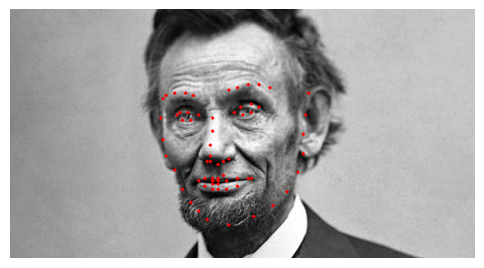

[array([[194., 140.],
        [197., 168.],
        [201., 189.],
        [212., 207.],
        [222., 232.],
        [233., 249.],
        [243., 260.],
        [254., 271.],
        [282., 278.],
        [314., 267.],
        [339., 253.],
        [357., 235.],
        [371., 210.],
        [378., 186.],
        [378., 161.],
        [381., 136.],
        [385., 108.],
        [197., 115.],
        [201., 111.],
        [212., 108.],
        [226., 108.],
        [236., 111.],
        [282., 104.],
        [293., 101.],
        [307.,  97.],
        [321.,  97.],
        [335., 101.],
        [261., 140.],
        [261., 157.],
        [258., 175.],
        [258., 189.],
        [254., 196.],
        [258., 196.],
        [268., 200.],
        [275., 196.],
        [282., 193.],
        [215., 136.],
        [219., 133.],
        [229., 133.],
        [243., 136.],
        [233., 143.],
        [222., 143.],
        [289., 133.],
        [297., 126.],
        [311., 122.],
        [3

In [16]:
detect_and_draw("../data/raw/OriginalImages/Abraham Lincoln/P00001.jpg")